In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Telecom Customer Retention") \
    .master("local[*]") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark session created successfully!")

Spark version: 3.1.1
Spark session created successfully!


In [3]:
from pyspark.sql import SparkSession, DataFrame

# Reuse/create Spark session
spark = SparkSession.builder \
    .appName("Telecom Customer Retention") \
    .master("local[*]") \
    .getOrCreate()

print("=== Spark Session Verification ===")
print("Spark version    :", spark.version)
print("Application name :", spark.sparkContext.appName)
print("Master           :", spark.sparkContext.master)

print("\n=== DataFrame Verification ===")
print("DataFrame class  :", DataFrame)

print("\n=== Common DataFrame Operations ===")
operations = [
    "select()", "filter()", "groupBy()", "agg()",
    "join()", "orderBy()", "withColumn()", "drop()",
    "show()", "describe()"
]

for operation in operations:
    print("✓", operation)

print("\n✓ Spark session and DataFrame support are working!")

=== Spark Session Verification ===
Spark version    : 3.1.1
Application name : Telecom Customer Retention
Master           : local[*]

=== DataFrame Verification ===
DataFrame class  : <class 'pyspark.sql.dataframe.DataFrame'>

=== Common DataFrame Operations ===
✓ select()
✓ filter()
✓ groupBy()
✓ agg()
✓ join()
✓ orderBy()
✓ withColumn()
✓ drop()
✓ show()
✓ describe()

✓ Spark session and DataFrame support are working!


In [4]:
# Load Telecom Customer Churn dataset from HDFS

hdfs_path = "hdfs://namenode:8020/telecom_retention/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", '"') \
    .option("escape", '"') \
    .csv(hdfs_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns)

Dataset loaded successfully!
Number of rows: 7043
Number of columns: 21

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
from pyspark.sql import functions as F

# ============================================================
# 1. Remove leading/trailing whitespace from string columns
# ============================================================

string_columns = [
    "customerID", "gender", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "Churn"
]

for col_name in string_columns:
    df = df.withColumn(col_name, F.trim(F.col(col_name)))


# ============================================================
# 2. Convert TotalCharges from STRING to DOUBLE
#    Blank values are converted to NULL
# ============================================================

df = df.withColumn(
    "TotalCharges",
    F.when(
        F.trim(F.col("TotalCharges")) == "",
        None
    ).otherwise(F.col("TotalCharges").cast("double"))
)


# ============================================================
# 3. Remove duplicate customer records
# ============================================================

before_duplicates = df.count()

df = df.dropDuplicates(["customerID"])

after_duplicates = df.count()


# ============================================================
# 4. Handle missing TotalCharges values
#    Use 0.0 for missing values
# ============================================================

missing_totalcharges = df.filter(
    F.col("TotalCharges").isNull()
).count()

df = df.fillna({
    "TotalCharges": 0.0
})


# ============================================================
# 5. Convert Churn into numerical target variable
#    No = 0
#    Yes = 1
# ============================================================

df = df.withColumn(
    "ChurnLabel",
    F.when(F.col("Churn") == "Yes", 1)
     .when(F.col("Churn") == "No", 0)
     .otherwise(None)
)


# ============================================================
# 6. Remove records with invalid Churn values
# ============================================================

df = df.filter(F.col("ChurnLabel").isNotNull())


# ============================================================
# 7. Display preprocessing summary
# ============================================================

print("========== PREPROCESSING SUMMARY ==========")
print("Rows before duplicate removal :", before_duplicates)
print("Rows after duplicate removal  :", after_duplicates)
print("Duplicate rows removed        :", before_duplicates - after_duplicates)
print("Missing TotalCharges handled  :", missing_totalcharges)
print("Final number of rows          :", df.count())
print("Final number of columns       :", len(df.columns))

print("\n========== DATA TYPES ==========")
df.printSchema()

print("\n========== SAMPLE DATA ==========")
df.show(5, truncate=False)

========== PREPROCESSING SUMMARY ==========
Rows before duplicate removal : 7043
Rows after duplicate removal  : 7043
Duplicate rows removed        : 0
Missing TotalCharges handled  : 11
Final number of rows          : 7043
Final number of columns       : 22

========== DATA TYPES ==========
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- Pape

In [6]:
from pyspark.sql import functions as F

# Overall customer counts
churn_summary = df.groupBy("Churn") \
    .count() \
    .withColumnRenamed("count", "CustomerCount") \
    .orderBy("Churn")

print("========== OVERALL CHURN ==========")
churn_summary.show()

# Calculate total customers
total_customers = df.count()

# Calculate churned customers
churned_customers = df.filter(F.col("Churn") == "Yes").count()

# Calculate churn percentage
churn_rate = (churned_customers / total_customers) * 100

print("Total customers :", total_customers)
print("Churned customers:", churned_customers)
print(f"Churn rate       : {churn_rate:.2f}%")

========== OVERALL CHURN ==========
+-----+-------------+
|Churn|CustomerCount|
+-----+-------------+
|   No|         5174|
|  Yes|         1869|
+-----+-------------+

Total customers : 7043
Churned customers: 1869
Churn rate       : 26.54%


In [7]:
from pyspark.sql import functions as F

contract_churn = df.groupBy("Contract") \
    .agg(
        F.count("*").alias("TotalCustomers"),
        F.sum(
            F.when(F.col("Churn") == "Yes", 1).otherwise(0)
        ).alias("ChurnedCustomers")
    ) \
    .withColumn(
        "ChurnRate",
        F.round(
            F.col("ChurnedCustomers") / F.col("TotalCustomers") * 100,
            2
        )
    ) \
    .orderBy(F.desc("ChurnRate"))

print("========== CHURN BY CONTRACT ==========")
contract_churn.show(truncate=False)

========== CHURN BY CONTRACT ==========
+--------------+--------------+----------------+---------+
|Contract      |TotalCustomers|ChurnedCustomers|ChurnRate|
+--------------+--------------+----------------+---------+
|Month-to-month|3875          |1655            |42.71    |
|One year      |1473          |166             |11.27    |
|Two year      |1695          |48              |2.83     |
+--------------+--------------+----------------+---------+



In [8]:
from pyspark.sql import functions as F

internet_churn = df.groupBy("InternetService") \
    .agg(
        F.count("*").alias("TotalCustomers"),
        F.sum(
            F.when(F.col("Churn") == "Yes", 1).otherwise(0)
        ).alias("ChurnedCustomers")
    ) \
    .withColumn(
        "ChurnRate",
        F.round(
            F.col("ChurnedCustomers") /
            F.col("TotalCustomers") * 100,
            2
        )
    ) \
    .orderBy(F.desc("ChurnRate"))

print("========== CHURN BY INTERNET SERVICE ==========")
internet_churn.show(truncate=False)

========== CHURN BY INTERNET SERVICE ==========
+---------------+--------------+----------------+---------+
|InternetService|TotalCustomers|ChurnedCustomers|ChurnRate|
+---------------+--------------+----------------+---------+
|Fiber optic    |3096          |1297            |41.89    |
|DSL            |2421          |459             |18.96    |
|No             |1526          |113             |7.4      |
+---------------+--------------+----------------+---------+



In [9]:
from pyspark.sql import functions as F

payment_churn = df.groupBy("PaymentMethod") \
    .agg(
        F.count("*").alias("TotalCustomers"),
        F.sum(
            F.when(F.col("Churn") == "Yes", 1).otherwise(0)
        ).alias("ChurnedCustomers")
    ) \
    .withColumn(
        "ChurnRate",
        F.round(
            F.col("ChurnedCustomers") /
            F.col("TotalCustomers") * 100,
            2
        )
    ) \
    .orderBy(F.desc("ChurnRate"))

print("========== CHURN BY PAYMENT METHOD ==========")
payment_churn.show(truncate=False)

========== CHURN BY PAYMENT METHOD ==========
+-------------------------+--------------+----------------+---------+
|PaymentMethod            |TotalCustomers|ChurnedCustomers|ChurnRate|
+-------------------------+--------------+----------------+---------+
|Electronic check         |2365          |1071            |45.29    |
|Mailed check             |1612          |308             |19.11    |
|Bank transfer (automatic)|1544          |258             |16.71    |
|Credit card (automatic)  |1522          |232             |15.24    |
+-------------------------+--------------+----------------+---------+



In [10]:
from pyspark.sql import functions as F

senior_churn = df.groupBy("SeniorCitizen") \
    .agg(
        F.count("*").alias("TotalCustomers"),
        F.sum(
            F.when(F.col("Churn") == "Yes", 1).otherwise(0)
        ).alias("ChurnedCustomers")
    ) \
    .withColumn(
        "ChurnRate",
        F.round(
            F.col("ChurnedCustomers") /
            F.col("TotalCustomers") * 100,
            2
        )
    ) \
    .withColumn(
        "CustomerType",
        F.when(F.col("SeniorCitizen") == 1, "Senior Citizen")
         .otherwise("Non-Senior Citizen")
    ) \
    .select(
        "CustomerType",
        "TotalCustomers",
        "ChurnedCustomers",
        "ChurnRate"
    ) \
    .orderBy(F.desc("ChurnRate"))

print("========== CHURN BY SENIOR CITIZEN STATUS ==========")
senior_churn.show(truncate=False)

========== CHURN BY SENIOR CITIZEN STATUS ==========
+------------------+--------------+----------------+---------+
|CustomerType      |TotalCustomers|ChurnedCustomers|ChurnRate|
+------------------+--------------+----------------+---------+
|Senior Citizen    |1142          |476             |41.68    |
|Non-Senior Citizen|5901          |1393            |23.61    |
+------------------+--------------+----------------+---------+



In [11]:
from pyspark.sql import functions as F

# Create tenure groups
df_tenure = df.withColumn(
    "TenureGroup",
    F.when(F.col("tenure") <= 12, "0-12 months")
     .when(F.col("tenure") <= 24, "13-24 months")
     .when(F.col("tenure") <= 36, "25-36 months")
     .when(F.col("tenure") <= 48, "37-48 months")
     .otherwise("49+ months")
)

# Calculate churn statistics
tenure_churn = df_tenure.groupBy("TenureGroup") \
    .agg(
        F.count("*").alias("TotalCustomers"),
        F.sum(
            F.when(F.col("Churn") == "Yes", 1).otherwise(0)
        ).alias("ChurnedCustomers")
    ) \
    .withColumn(
        "ChurnRate",
        F.round(
            F.col("ChurnedCustomers") /
            F.col("TotalCustomers") * 100,
            2
        )
    ) \
    .orderBy("TenureGroup")

print("========== CHURN BY TENURE GROUP ==========")
tenure_churn.show(truncate=False)

========== CHURN BY TENURE GROUP ==========
+------------+--------------+----------------+---------+
|TenureGroup |TotalCustomers|ChurnedCustomers|ChurnRate|
+------------+--------------+----------------+---------+
|0-12 months |2186          |1037            |47.44    |
|13-24 months|1024          |294             |28.71    |
|25-36 months|832           |180             |21.63    |
|37-48 months|762           |145             |19.03    |
|49+ months  |2239          |213             |9.51     |
+------------+--------------+----------------+---------+



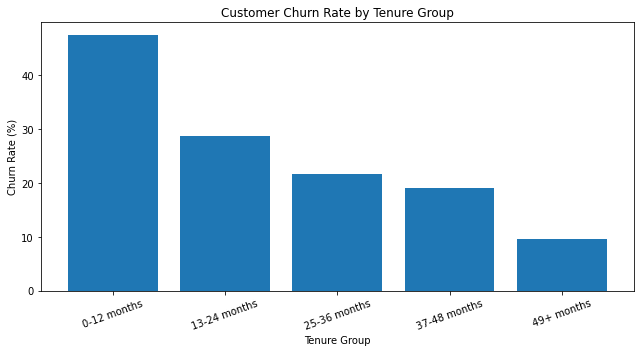

In [12]:
import matplotlib.pyplot as plt

# Convert the Spark aggregation to Pandas
tenure_pd = tenure_churn.toPandas()

# Create bar chart
plt.figure(figsize=(9, 5))

plt.bar(
    tenure_pd["TenureGroup"],
    tenure_pd["ChurnRate"]
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

========== CHURN BY PAYMENT METHOD ==========
+-------------------------+--------------+----------------+---------+
|PaymentMethod            |TotalCustomers|ChurnedCustomers|ChurnRate|
+-------------------------+--------------+----------------+---------+
|Electronic check         |2365          |1071            |45.29    |
|Mailed check             |1612          |308             |19.11    |
|Bank transfer (automatic)|1544          |258             |16.71    |
|Credit card (automatic)  |1522          |232             |15.24    |
+-------------------------+--------------+----------------+---------+



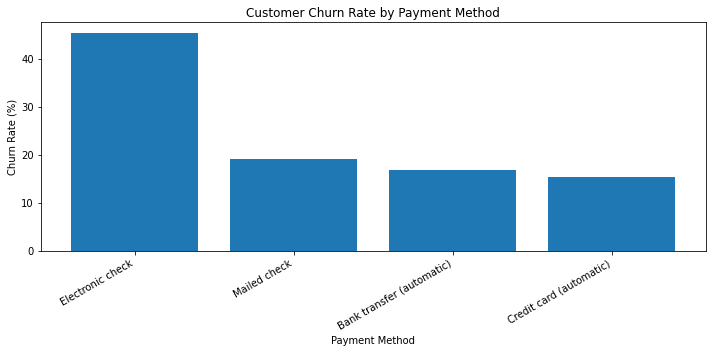

In [13]:
import matplotlib.pyplot as plt

# Display the Spark results
print("========== CHURN BY PAYMENT METHOD ==========")
payment_churn.show(truncate=False)

# Convert the aggregated Spark DataFrame to Pandas
payment_pd = payment_churn.toPandas()

# Create bar chart
plt.figure(figsize=(10, 5))

plt.bar(
    payment_pd["PaymentMethod"],
    payment_pd["ChurnRate"]
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

========== CHURN BY SENIOR CITIZEN STATUS ==========
+------------------+--------------+----------------+---------+
|CustomerType      |TotalCustomers|ChurnedCustomers|ChurnRate|
+------------------+--------------+----------------+---------+
|Senior Citizen    |1142          |476             |41.68    |
|Non-Senior Citizen|5901          |1393            |23.61    |
+------------------+--------------+----------------+---------+



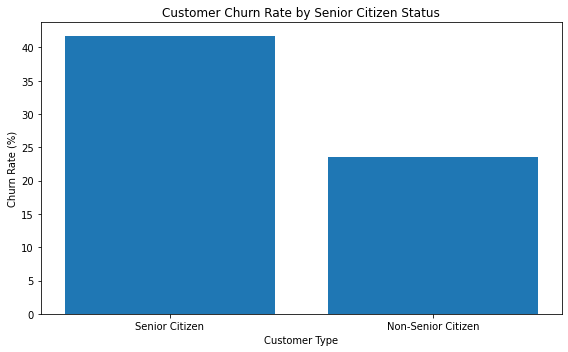

In [14]:
import matplotlib.pyplot as plt

# Display the Spark results
print("========== CHURN BY SENIOR CITIZEN STATUS ==========")
senior_churn.show(truncate=False)

# Convert Spark DataFrame to Pandas
senior_pd = senior_churn.toPandas()

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    senior_pd["CustomerType"],
    senior_pd["ChurnRate"]
)

plt.title("Customer Churn Rate by Senior Citizen Status")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

========== CHURN BY CONTRACT TYPE ==========
+--------------+--------------+----------------+---------+
|Contract      |TotalCustomers|ChurnedCustomers|ChurnRate|
+--------------+--------------+----------------+---------+
|Month-to-month|3875          |1655            |42.71    |
|One year      |1473          |166             |11.27    |
|Two year      |1695          |48              |2.83     |
+--------------+--------------+----------------+---------+



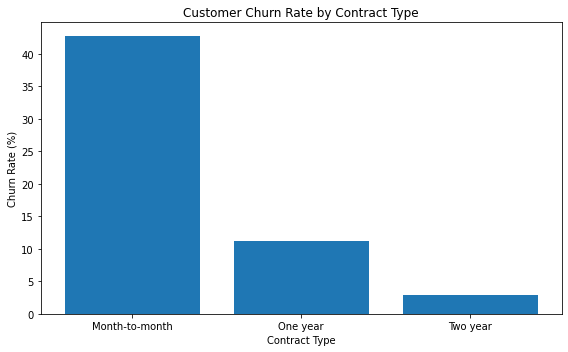

In [15]:
import matplotlib.pyplot as plt

# Display Spark results
print("========== CHURN BY CONTRACT TYPE ==========")
contract_churn.show(truncate=False)

# Convert Spark DataFrame to Pandas
contract_pd = contract_churn.toPandas()

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    contract_pd["Contract"],
    contract_pd["ChurnRate"]
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# PYSPARK MLlib - TELECOM CUSTOMER CHURN PREDICTION
# ============================================================

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql import functions as F

# ------------------------------------------------------------
# 1. Define categorical and numerical features
# ------------------------------------------------------------

categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# ------------------------------------------------------------
# 2. Remove records with missing feature values
# ------------------------------------------------------------

model_df = df.select(
    categorical_cols + numeric_cols + ["ChurnLabel"]
).dropna()

print("Rows available for ML:", model_df.count())

# ------------------------------------------------------------
# 3. Convert categorical columns to numerical indexes
# ------------------------------------------------------------

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]

# ------------------------------------------------------------
# 4. One-hot encode categorical variables
# ------------------------------------------------------------

indexed_cols = [col + "_index" for col in categorical_cols]
encoded_cols = [col + "_encoded" for col in categorical_cols]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=encoded_cols
)

# ------------------------------------------------------------
# 5. Combine all features into one vector
# ------------------------------------------------------------

assembler = VectorAssembler(
    inputCols=encoded_cols + numeric_cols,
    outputCol="features"
)

# ------------------------------------------------------------
# 6. Create Logistic Regression model
# ------------------------------------------------------------

lr = LogisticRegression(
    featuresCol="features",
    labelCol="ChurnLabel",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    maxIter=50
)

# ------------------------------------------------------------
# 7. Build ML pipeline
# ------------------------------------------------------------

pipeline = Pipeline(
    stages=indexers + [encoder, assembler, lr]
)

# ------------------------------------------------------------
# 8. Train-test split
# ------------------------------------------------------------

train_df, test_df = model_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

# ------------------------------------------------------------
# 9. Train the model
# ------------------------------------------------------------

model = pipeline.fit(train_df)

print("\n✓ Logistic Regression model trained successfully!")

# ------------------------------------------------------------
# 10. Make predictions
# ------------------------------------------------------------

predictions = model.transform(test_df)

print("\n========== SAMPLE PREDICTIONS ==========")

predictions.select(
    "ChurnLabel",
    "prediction",
    "probability"
).show(10, truncate=False)

# ------------------------------------------------------------
# 11. Evaluate Accuracy
# ------------------------------------------------------------

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="ChurnLabel",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

# ------------------------------------------------------------
# 12. Evaluate Precision
# ------------------------------------------------------------

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="ChurnLabel",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

precision = precision_evaluator.evaluate(predictions)

# ------------------------------------------------------------
# 13. Evaluate Recall
# ------------------------------------------------------------

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="ChurnLabel",
    predictionCol="prediction",
    metricName="weightedRecall"
)

recall = recall_evaluator.evaluate(predictions)

# ------------------------------------------------------------
# 14. Evaluate F1 Score
# ------------------------------------------------------------

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="ChurnLabel",
    predictionCol="prediction",
    metricName="f1"
)

f1 = f1_evaluator.evaluate(predictions)

# ------------------------------------------------------------
# 15. Evaluate AUC
# ------------------------------------------------------------

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="ChurnLabel",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = auc_evaluator.evaluate(predictions)

# ------------------------------------------------------------
# 16. Display final metrics
# ------------------------------------------------------------

print("\n========== MODEL EVALUATION ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

# ------------------------------------------------------------
# 17. Confusion Matrix
# ------------------------------------------------------------

print("\n========== CONFUSION MATRIX ==========")

confusion_matrix = predictions.groupBy(
    "ChurnLabel",
    "prediction"
).count().orderBy(
    "ChurnLabel",
    "prediction"
)

confusion_matrix.show()

Rows available for ML: 7043
Training records: 5609
Testing records : 1434

✓ Logistic Regression model trained successfully!

========== SAMPLE PREDICTIONS ==========
+----------+----------+-----------------------------------------+
|ChurnLabel|prediction|probability                              |
+----------+----------+-----------------------------------------+
|0         |0.0       |[0.7918354332581842,0.20816456674181583] |
|0         |0.0       |[0.9153146443324444,0.08468535566755564] |
|0         |0.0       |[0.6047021972077821,0.39529780279221793] |
|1         |0.0       |[0.5402339205930866,0.4597660794069134]  |
|0         |0.0       |[0.8908290529990139,0.10917094700098606] |
|0         |0.0       |[0.788757129795191,0.21124287020480903]  |
|1         |1.0       |[0.2079466099241491,0.7920533900758508]  |
|0         |0.0       |[0.6748238701273214,0.32517612987267863] |
|0         |0.0       |[0.7450824630455385,0.2549175369544615]  |
|0         |0.0       |[0.978429346889086

========== CONFUSION MATRIX ==========
                 Predicted
                 No     Yes
Actual No         953    109
Actual Yes        180    192


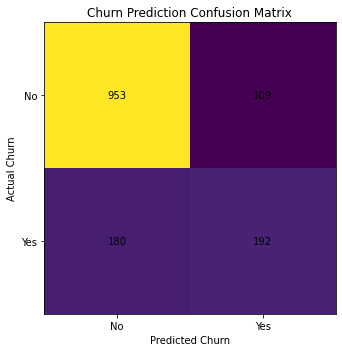

In [18]:
import matplotlib.pyplot as plt

# Get confusion matrix values from Spark
cm = predictions.groupBy(
    "ChurnLabel",
    "prediction"
).count().collect()

# Initialize 2x2 matrix
matrix = [[0, 0], [0, 0]]

for row in cm:
    actual = int(row["ChurnLabel"])
    predicted = int(row["prediction"])
    matrix[actual][predicted] = row["count"]

print("========== CONFUSION MATRIX ==========")
print("                 Predicted")
print("                 No     Yes")
print(f"Actual No       {matrix[0][0]:5d}  {matrix[0][1]:5d}")
print(f"Actual Yes      {matrix[1][0]:5d}  {matrix[1][1]:5d}")

# Plot
plt.figure(figsize=(7, 5))

plt.imshow(matrix)

plt.title("Churn Prediction Confusion Matrix")
plt.xlabel("Predicted Churn")
plt.ylabel("Actual Churn")

plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])

# Add values inside cells
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(matrix[i][j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()